In [5]:
import torch

print("PyTorch Version :", torch.__version__)
print("CUDA Available  :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name        :", torch.cuda.get_device_name(0))
    print("GPU Count       :", torch.cuda.device_count())

PyTorch Version : 2.10.0+cu128
CUDA Available  : True
GPU Name        : Tesla T4
GPU Count       : 2


In [6]:
!pip install transformers==4.56.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 89.9 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 34.7 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.10.1
    Uninstalling huggingface_hub-1.10.1:
      Successfully uninstalled huggingface_hub-1.10.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [7]:
import torch

if torch.cuda.is_available():
    free, total = torch.cuda.mem_get_info()

    print(f"Free GPU Memory : {free/1024**3:.2f} GB")
    print(f"Total GPU Memory: {total/1024**3:.2f} GB")

Free GPU Memory : 14.46 GB
Total GPU Memory: 14.56 GB


In [9]:
import transformers
print(transformers.__version__)

4.56.2


In [10]:
import torch
import cv2
import PIL
import accelerate
import sentencepiece

from transformers import AutoProcessor, AutoModel

print("✅ All imports successful")

2026-06-29 07:39:50.680803: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782718790.920074      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782718790.989198      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782718791.522071      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782718791.522109      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782718791.522112      58 computation_placer.cc:177] computation placer alr

✅ All imports successful


In [11]:
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")

MODEL_NAME = "nvidia/LocateAnything-3B"

In [12]:
!pip install decord lmdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 96.0 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.3/338.3 kB 27.2 MB/s eta 0:00:00


In [13]:
processor = AutoProcessor.from_pretrained(
    MODEL_NAME,
    token=hf_token,
    trust_remote_code=True
)

print("✅ Processor Loaded Successfully")

processor_config.json:   0%|          | 0.00/493 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

processing_locateanything.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/nvidia/LocateAnything-3B:
- processing_locateanything.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


preprocessor_config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

✅ Processor Loaded Successfully


In [14]:
model = AutoModel.from_pretrained(
    MODEL_NAME,
    token=hf_token,
    trust_remote_code=True,
    dtype=torch.float16,
    device_map="auto"
)

print("✅ Model Loaded Successfully")

config.json: 0.00B [00:00, ?B/s]

configuration_locateanything.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/nvidia/LocateAnything-3B:
- configuration_locateanything.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_locateanything.py: 0.00B [00:00, ?B/s]

generate_utils.py: 0.00B [00:00, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/2.70G [00:00<?, ?B/s]

Qwen2ForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/121 [00:00<?, ?B/s]

✅ Model Loaded Successfully


✅ Image Loaded Successfully
Size : (299, 168)
Mode : RGB


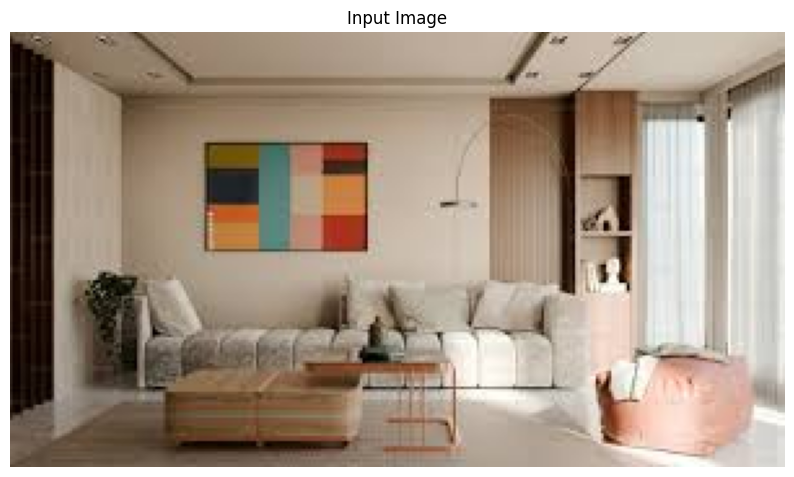

In [16]:
from PIL import Image
import matplotlib.pyplot as plt

IMAGE_PATH = "/kaggle/input/datasets/vidhikhatarkar06/locateanything-images/livingROOM.jpg"

# Load image
image = Image.open(IMAGE_PATH).convert("RGB")

# Print information
print("✅ Image Loaded Successfully")
print("Size :", image.size)
print("Mode :", image.mode)

# Display image
plt.figure(figsize=(10, 8))
plt.imshow(image)
plt.axis("off")
plt.title("Input Image")
plt.show()

In [44]:
query = input("Enter your query: ")

print(query)

Enter your query:  find chair


find chair


In [18]:
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image
            },
            {
                "type": "text",
                "text": query
            }
        ]
    }
]

In [19]:
text = processor.py_apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

print(text)

<|im_start|>system
You are a helpful assistant.
<|im_end|>
<|im_start|>user
<image-1>Find the chair<|im_end|>
<|im_start|>assistant



In [21]:
images, videos = processor.process_vision_info(messages)

In [30]:
inputs = processor(
    text=[text],
    images=images,
    videos=videos,
    return_tensors="pt"
)

inputs = {k: v.to(model.device) if hasattr(v, "to") else v
          for k, v in inputs.items()}

In [31]:
import torch

pixel_values = inputs["pixel_values"].to(model.dtype)

with torch.no_grad():
    response = model.generate(
        pixel_values=pixel_values,
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        image_grid_hws=inputs.get("image_grid_hws", None),
        tokenizer=processor.tokenizer,
        generation_mode="hybrid",
        max_new_tokens=10,
        use_cache=True,
        temperature=0.7,
        do_sample=True,
        top_p=0.9,
        repetition_penalty=1.1,
        verbose=True,
    )

print("Generation completed!")
print(type(response))


Statistic Info, num_tokens=10; generate_time(s)=0.2947; tps=33.9305; forward_step=3; num_boxes=1; bps=3.3930; prefill_time=0.1469; switch_to_ar=0

Generation completed!
<class 'tuple'>


Generated Output:
<ref>chair the</ref><box><753><730><963><995></box>

Detected Object: chair

Normalized Coordinates:
753 730 963 995

Pixel Coordinates:
225 122 287 167


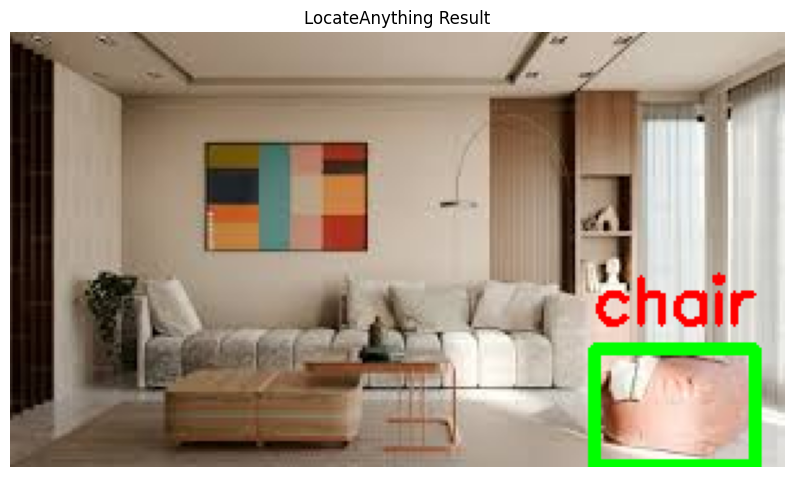

In [42]:
import re
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Get model output
# -----------------------------
generated_text = response[0]

print("Generated Output:")
print(generated_text)

# -----------------------------
# Extract object label
# -----------------------------
label_match = re.search(r"<ref>(.*?)</ref>", generated_text)

if label_match:
    object_name = label_match.group(1).strip()
else:
    object_name = "Object"

# Optional cleanup
object_name = object_name.replace(" the", "").strip()

print("\nDetected Object:", object_name)

# -----------------------------
# Extract first bounding box
# -----------------------------
box_match = re.search(
    r"<box><(\d+)><(\d+)><(\d+)><(\d+)></box>",
    generated_text
)

if box_match:

    x1, y1, x2, y2 = map(int, box_match.groups())

    print("\nNormalized Coordinates:")
    print(x1, y1, x2, y2)

    # -----------------------------
    # Convert to pixel coordinates
    # -----------------------------
    width, height = image.size

    x1 = int(x1 / 1000 * width)
    y1 = int(y1 / 1000 * height)
    x2 = int(x2 / 1000 * width)
    y2 = int(y2 / 1000 * height)

    print("\nPixel Coordinates:")
    print(x1, y1, x2, y2)

    # -----------------------------
    # Draw bounding box
    # -----------------------------
    img = np.array(image).copy()

    cv2.rectangle(
        img,
        (x1, y1),
        (x2, y2),
        (0,255,0),
        3
    )

    cv2.putText(
        img,
        object_name,
        (x1, max(25, y1-10)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255,0,0),
        2
    )

    plt.figure(figsize=(10,6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("LocateAnything Result")
    plt.show()

else:
    print("No bounding box found.")